In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('result.csv')

batch_data = data[data['insert_size'] != 1]

In [3]:
data.describe()

,insert_size,repeat_no,instance_build_seconds,insert_seconds,total_seconds,avg_row_insert_sec
count,100.000000,100.000000,90.000000,100.000000,100.000000,10.000000
mean,16666.100000,5.500000,0.337509,5.689588,5.995099,0.000380
std,31540.696349,2.886751,0.010529,10.834978,10.738580,0.000003
min,1.000000,1.000000,0.317770,1.603662,1.936178,0.000376
25%,50.000000,3.000000,0.331735,1.843403,2.172507,0.000379
50%,750.000000,5.500000,0.337728,2.105722,2.448570,0.000380
75%,10000.000000,8.000000,0.344347,2.664895,3.011063,0.000381
max,100000.000000,10.000000,0.376174,38.425144,38.442091,0.000384


In [4]:
batch_data.drop('avg_row_insert_sec', axis=1).describe()

,insert_size,repeat_no,instance_build_seconds,insert_seconds,total_seconds
count,90.000000,90.000000,90.000000,90.000000,90.000000
mean,18517.777778,5.500000,0.337509,2.098113,2.435624
std,32740.192383,2.888373,0.010529,0.379164,0.380159
min,10.000000,1.000000,0.317770,1.603662,1.936178
25%,100.000000,3.000000,0.331735,1.774542,2.111295
50%,1000.000000,5.500000,0.337728,2.092388,2.433285
75%,10000.000000,8.000000,0.344347,2.236971,2.577104
max,100000.000000,10.000000,0.376174,2.839045,3.158455


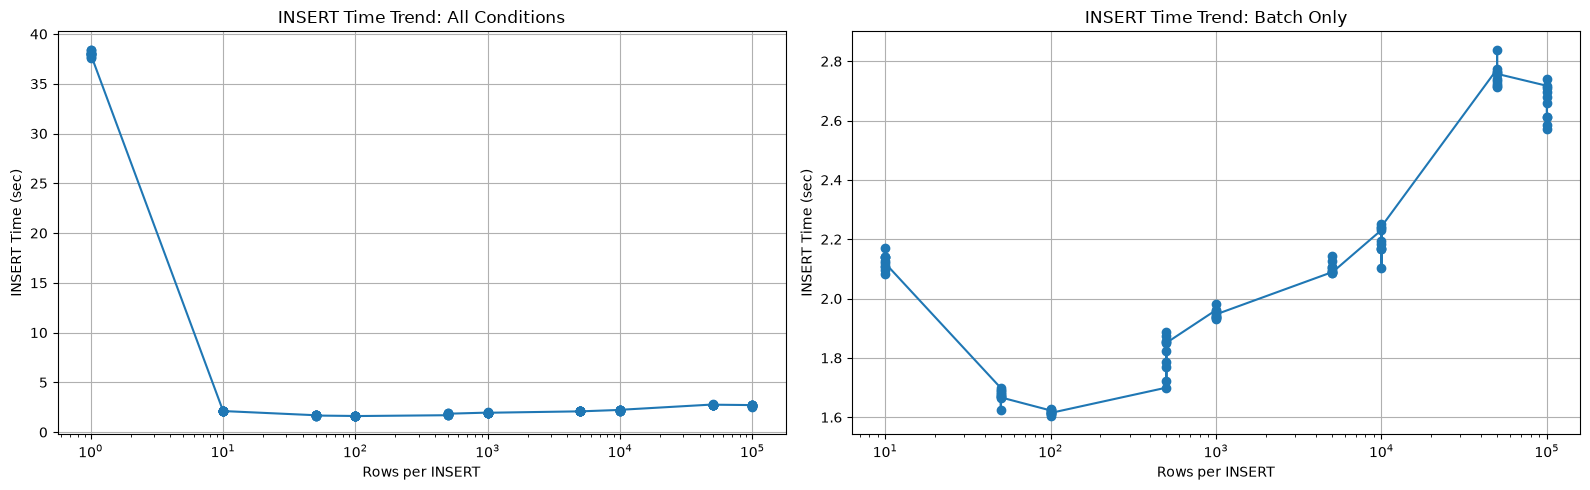

In [5]:
plt.figure(figsize=(16, 5))

plt.subplot(1, 2, 1)
plt.plot(data['insert_size'], data['insert_seconds'], marker='o')
plt.xscale('log')
plt.title('INSERT Time Trend: All Conditions')
plt.xlabel('Rows per INSERT')
plt.ylabel('INSERT Time (sec)')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(batch_data['insert_size'], batch_data['insert_seconds'], marker='o')
plt.xscale('log')
plt.title('INSERT Time Trend: Batch Only')
plt.xlabel('Rows per INSERT')
plt.ylabel('INSERT Time (sec)')
plt.grid(True)

plt.tight_layout()
plt.show()

In [6]:
instance_build_per_row_sec = batch_data['instance_build_seconds'].mean() / 100_000
insert_once_per_instance_build_per_row_sec = data['avg_row_insert_sec'].mean() / instance_build_per_row_sec
break_even_rows = batch_data['instance_build_seconds'].mean() / data['avg_row_insert_sec'].mean()

print(f'{instance_build_per_row_sec:.9f}')
print(f'{insert_once_per_instance_build_per_row_sec:.2f}')
print(break_even_rows)

0.000003375
112.63
887.8816805685766


In [9]:
insert_once = data['avg_row_insert_sec'].mean()

print(f'인스턴스 빌드: {batch_data['instance_build_seconds'].mean():.4f}')
print(f'250회 단순연산: {250 * insert_once:.4f}')
print(f'500회 단순연산: {500 * insert_once:.4f}')
print(f'750회 단순연산: {750 * insert_once:.4f}')
print(f'1000회 단순연산: {1000 * insert_once:.4f}')

인스턴스 빌드: 0.3375
250회 단순연산: 0.0950
500회 단순연산: 0.1901
750회 단순연산: 0.2851
1000회 단순연산: 0.3801
